In [ ]:
import torch
from astropy.io import fits
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
import torchvision.transforms.v2 as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from fastai.basics import *
from fastai.vision.all import *
import os
import torchvision
import torch.nn.init as init
from torchinfo import summary
import torch.optim as optim
from tqdm import tqdm


In [3]:
IMAGE_FOLDER = r"\\wsl.localhost\Ubuntu\home\tuannbas\GRADMAP_SS26\GRADMAP_SS26\training_dataset_folder\training"  # Path to your local image folder
IMAGE_EXTENSION = ".jpg"

In [4]:
TEST_IMAGE_FOLDER = r"\\wsl.localhost\Ubuntu\home\tuannbas\GRADMAP_SS26\GRADMAP_SS26\training_dataset_folder\test"

In [5]:
TEST_IMAGE_PATH = r"\\wsl.localhost\Ubuntu\home\tuannbas\GRADMAP_SS26\GRADMAP_SS26\lol"

In [6]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('PyTorch:', torch.__version__)
print('CUDA version:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')

CUDA available: True
PyTorch: 2.12.1+cu130
CUDA version: 13.0
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [7]:
transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.ToDtype(torch.float32, scale=True), 
    transforms.Normalize((0.5,), (0.5,)),
])

c:\Users\tuann\miniconda3\envs\CometGM\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
#The way to convert image to tensor
# 1.Open the image with Image.open
# 2.Define the transform function like above
# 3.transform the image with that transform function

In [8]:
dataset = torchvision.datasets.ImageFolder(IMAGE_FOLDER, transform=transforms)
test_dataset = torchvision.datasets.ImageFolder(TEST_IMAGE_FOLDER, transform=transforms)

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size    

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

In [10]:
batch_size = 64

train_dataloader = None
val_dataloader = None
test_dataloader = None

train_dataloader = torch.utils.data.DataLoader(train_dataset)
val_dataloader = torch.utils.data.DataLoader(val_dataset)
test_dataloader = torch.utils.data.DataLoader(test_dataset)

print(f"{len(train_dataloader) = }")
print(f"{len(val_dataloader) = }")
print(f"{len(test_dataloader) = }")

len(train_dataloader) = 7180
len(val_dataloader) = 1796
len(test_dataloader) = 567


In [117]:
# # batch layer display
# def imshow(img, title=None):
#     img = img / 2 + 0.5  # unormalize
#     npimg = img.numpy()
#     plt.figure(figsize=(6, 6))  # output size
#     plt.imshow(np.transpose(npimg, (1, 2, 0)))  # (C, H, W) → (H, W, C)
#     if title:
#         plt.title(title)
#     plt.axis('off')
#     plt.show()

# # a batch from dataloader
# # images, labels = next(iter(train_dataloader))
# data_iterator = iter(train_dataloader)


# images_batch1, labels_batch1 = next(data_iterator)
# images_batch2, labels_batch2 = next(data_iterator)
# images_batch3, labels_batch3 = next(data_iterator)



# # show a grid of images
# # imshow(torchvision.utils.make_grid(images))
# # print(labels)
# imshow(torchvision.utils.make_grid(images_batch1))
# print(labels_batch1)
# imshow(torchvision.utils.make_grid(images_batch2))
# print(labels_batch2)
# imshow(torchvision.utils.make_grid(images_batch3))
# print(labels_batch3)

In [11]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()

        #input
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        
        self.fc1 = nn.Linear(32*25*25, 128) 
        self.fc2 = nn.Linear(128, 2)

        # Strategic weight initialization
    #     self._initialize_weights()

    # def _initialize_weights(self):
    #     # Xavier initialization for fully connected layers
    #     init.xavier_uniform_(self.fc1.weight)
    #     init.zeros_(self.fc1.bias)

    #     init.xavier_uniform_(self.fc2.weight)
    #     init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNet()
model.to(device)
print(f"{device = }")
summary(model)

device = device(type='cuda')


Layer (type:depth-idx)                   Param #
NeuralNet                                --
├─Conv2d: 1-1                            160
├─Conv2d: 1-2                            4,640
├─MaxPool2d: 1-3                         --
├─Linear: 1-4                            2,560,128
├─Linear: 1-5                            258
Total params: 2,565,186
Trainable params: 2,565,186
Non-trainable params: 0

In [12]:
loss_fn = nn.CrossEntropyLoss()

In [13]:
def train(model, train_dataloader, loss_fn, optimizer):

    model.train()

    for i, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

In [14]:
def evaluate(model, dataloader, loss_fn):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = loss_fn(outputs, y)
            total_loss += loss.item() * X.size(0)  # accumulate weighted loss

            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == y).sum().item()
            total_samples += y.size(0)

    if total_samples == 0:
        return 0.0, 0.0  # avoid division by zero

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

In [60]:
num_epochs = 30
patience = 7
count = 0
best_loss = np.inf
early_stop = False

optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

for epoch in tqdm(range(num_epochs)):
    print(f"Training {epoch=}")
    train(model, train_dataloader, loss_fn, optimizer)
    scheduler.step()

    print(f"Evaluating {epoch=}")
    loss_train, acc_train = evaluate(model, train_dataloader, loss_fn)
    loss_val, acc_val = evaluate(model, val_dataloader, loss_fn)
    loss_test, acc_test = evaluate(model, test_dataloader, loss_fn)

    if loss_val < best_loss:
        best_loss = loss_val
        count = 0
        torch.save(model.state_dict(), "model8.h5")  # Save best model when accuracy improves
    else:
        count += 1
        print(f"Comet count: {count}/{patience}")
        if count >= patience:
            early_stop = True


    if early_stop:
        break
print("Complete")

  0%|          | 0/30 [00:00<?, ?it/s]

Training epoch=0
Evaluating epoch=0


  3%|▎         | 1/30 [01:53<54:39, 113.08s/it]

Training epoch=1
Evaluating epoch=1


  7%|▋         | 2/30 [03:52<54:36, 117.02s/it]

...

Comet count: 5/7
Training epoch=6
Evaluating epoch=6


 23%|██▎       | 7/30 [13:59<46:22, 120.99s/it]

Comet count: 6/7
Training epoch=7
Evaluating epoch=7


 23%|██▎       | 7/30 [16:01<52:39, 137.36s/it]

Comet count: 7/7
Complete


In [15]:
model.load_state_dict(torch.load("model8.h5"))
model.eval()


NeuralNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=20000, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [16]:
loss_test, acc_test = evaluate(model, val_dataloader, loss_fn)

print(f"Test Loss:     {loss_test:.4f}")
print(f"Test Accuracy: {acc_test * 100:.2f}%")

Test Loss:     0.2809
Test Accuracy: 94.93%


In [17]:
loss_test, acc_test = evaluate(model, test_dataloader, loss_fn)

print(f"Test Loss:     {loss_test:.4f}")
print(f"Test Accuracy: {acc_test * 100:.2f}%")

Test Loss:     0.0530
Test Accuracy: 98.59%


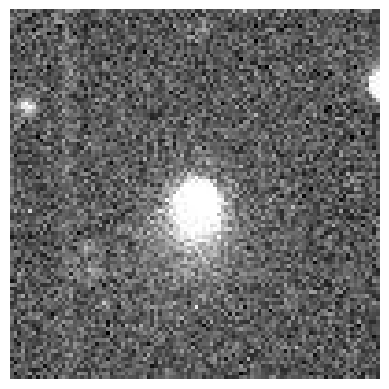

tensor([[ 2.1716, -2.1780]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [18]:
images, true_labels = next(iter(test_dataloader))
images = images.to(device)
outputs = model(images)

# ConfusionMatrixDisplay.from_predictions(
#     y_true=true_labels,
#     y_pred=0,
#     display_labels=["comet", "no comet"],  # Custom text labels
#     cmap=plt.cm.Blues                      # Color theme
# )
images = images.to(torch.device("cpu"))
images = images.squeeze()
plt.imshow(images.detach().cpu(), cmap='gray')
plt.axis('off')
plt.show()
print(outputs)

In [163]:
temp = r"\\wsl.localhost\Ubuntu\home\tuannbas\GRADMAP_SS26\GRADMAP_SS26\fits_hi1a_2011\hi1a_20111219_000901.fits"
hdul = fits.open(temp)
data = hdul[0].data

In [164]:
data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
data = data.astype(np.float32)

In [165]:
tensor_data = torch.from_numpy(data)

In [166]:
from astropy.visualization import ImageNormalize
from astropy.visualization import PercentileInterval
from astropy.visualization import imshow_norm, SinhStretch,AsinhStretch, PowerStretch, LinearStretch

norm = ImageNormalize(
    interval=PercentileInterval(99.5),
    stretch= AsinhStretch(),
    clip=True
)

img = norm(data)

In [167]:
import torchvision.transforms.v2 as transforms
transforms_1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.ToDtype(torch.float32, scale=True), 
    transforms.Normalize((0.5,), (0.5,)),
])

In [168]:
l = transforms_1(img)

In [169]:
l = l.squeeze(0)
print(l.shape)

torch.Size([1024, 1024])


In [170]:
temp = l[0:100,0:100]

In [ ]:
# import torch.nn.functional as F

# l = l.unsqueeze(0)  # [1, 1, 1024, 1024]

# image_100 = F.interpolate(
#     l,
#     size=(100, 100),
#     mode="bilinear",
#     align_corners=False
# )

# print(image_100.shape)

torch.Size([1, 1, 100, 100])


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

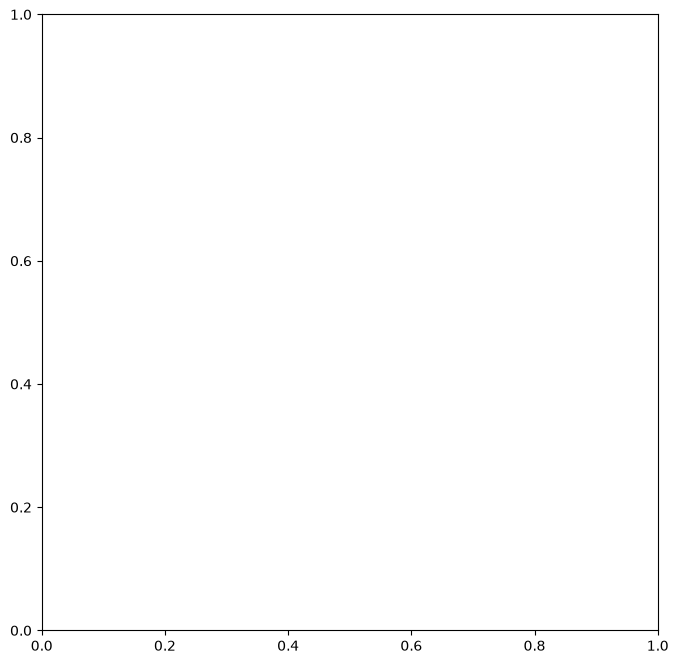

In [ ]:
# l = image_100.squeeze(0).squeeze(0)
# plt.figure(figsize=(8, 8))
# plt.imshow(patches[0], cmap='gray', origin='lower')

In [171]:
print(l.shape)

torch.Size([1024, 1024])


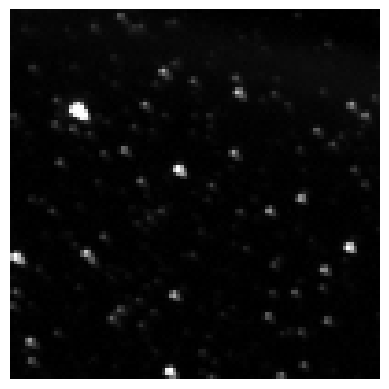

In [147]:
plt.imshow(temp.detach().cpu(), cmap='gray')
plt.axis('off')
plt.show()

In [172]:
unfold = torch.nn.Unfold(
    kernel_size=(100, 100),
    stride=(100, 100)
)
patches = unfold(l.unsqueeze(0).unsqueeze(0))

In [173]:
patches = patches.transpose(1, 2)
patches = patches.reshape(-1, 1, 100, 100)

print(patches.shape)

torch.Size([100, 1, 100, 100])


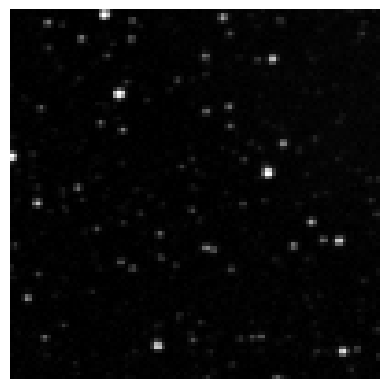

In [174]:
# patches[0] = patches[0].to(torch.device("cpu"))
plt.imshow(patches[6].squeeze().detach().cpu(), cmap='gray')
plt.axis('off')
plt.show()

In [175]:
patches = patches.float()

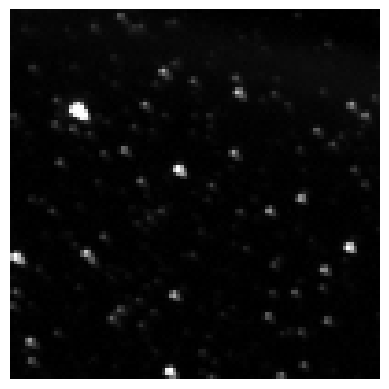

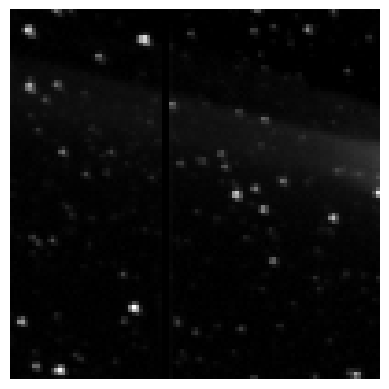

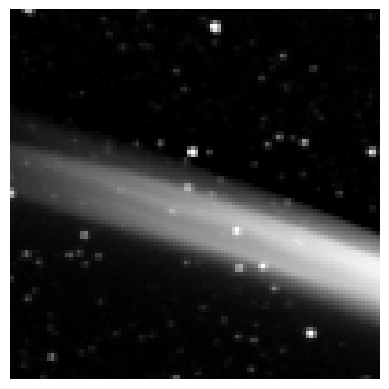

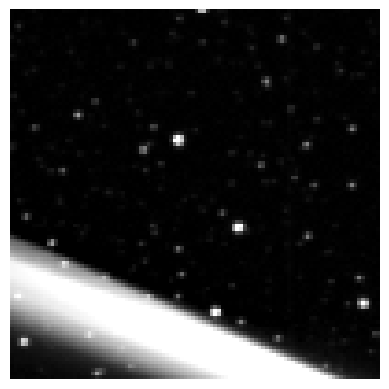

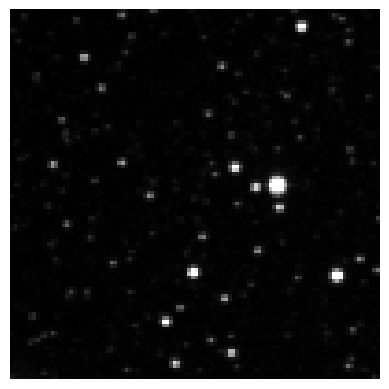

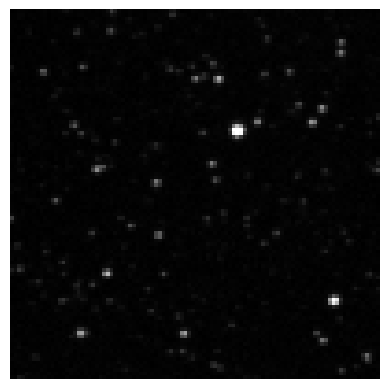

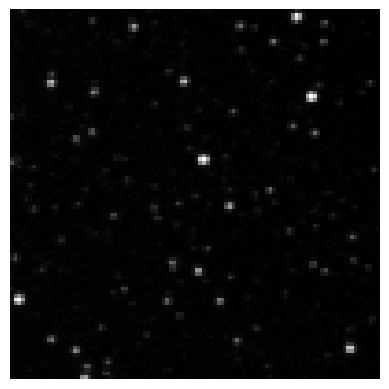

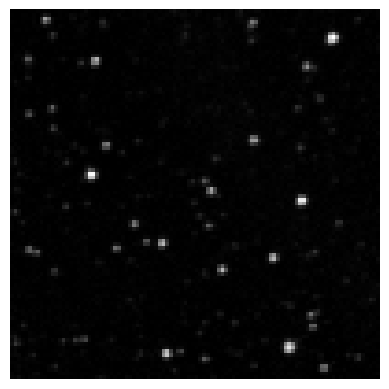

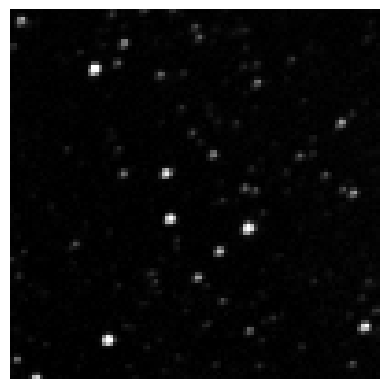

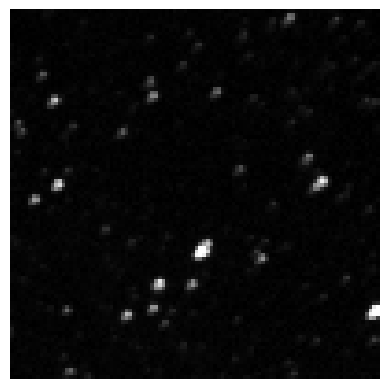

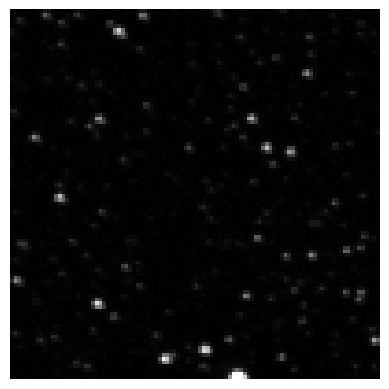

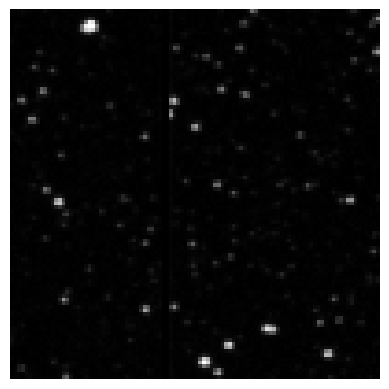

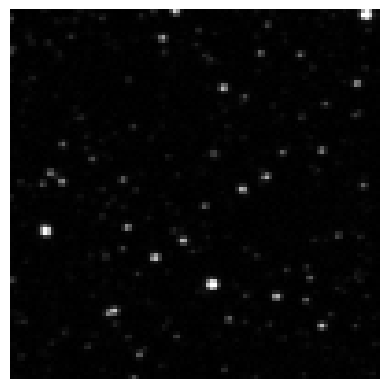

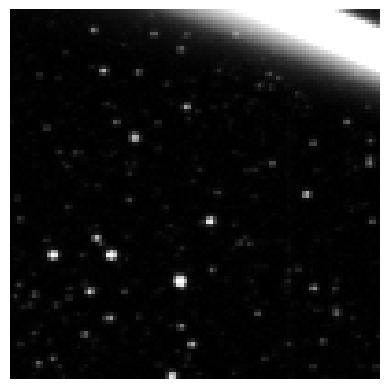

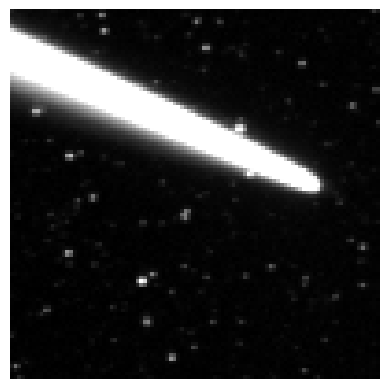

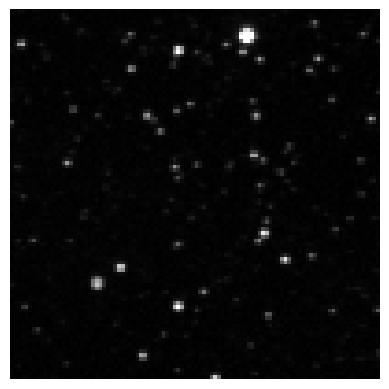

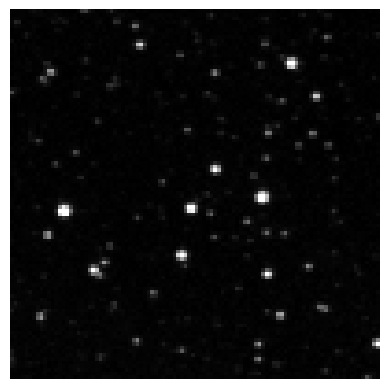

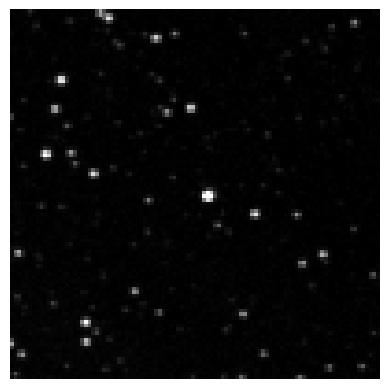

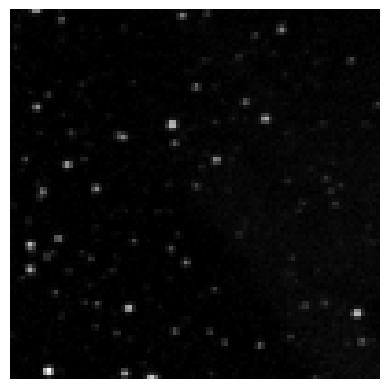

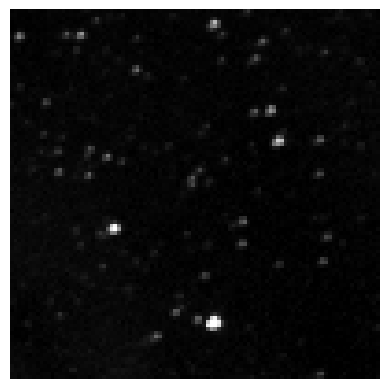

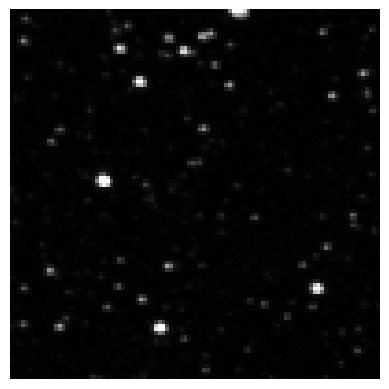

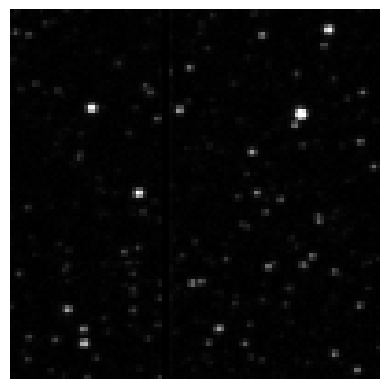

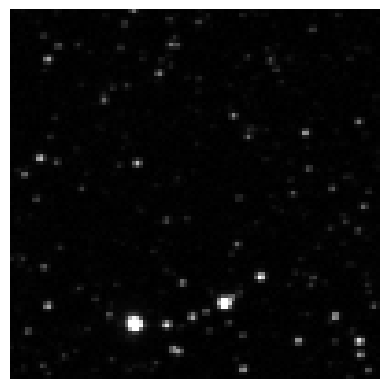

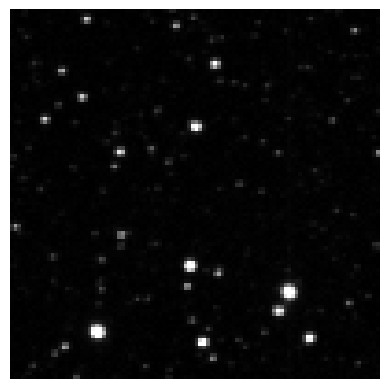

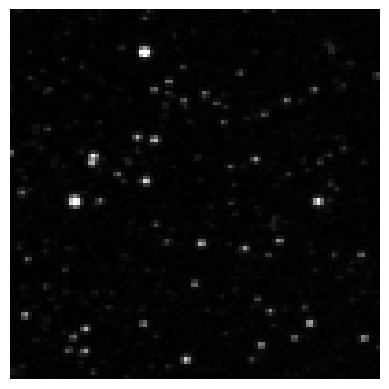

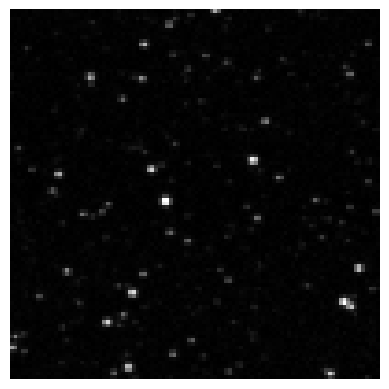

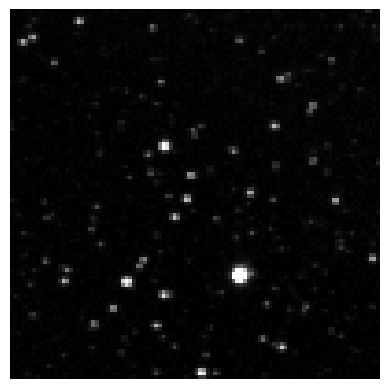

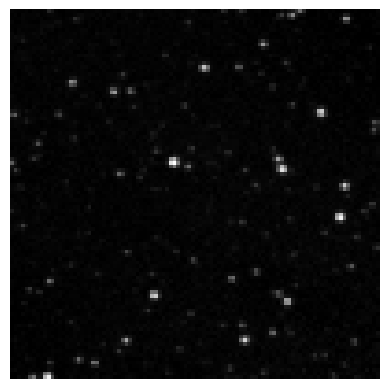

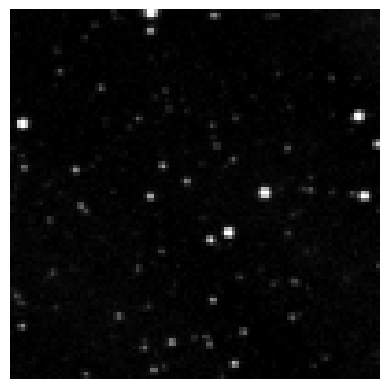

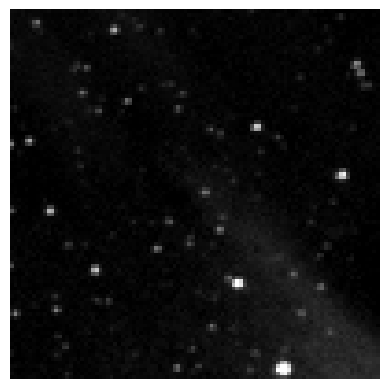

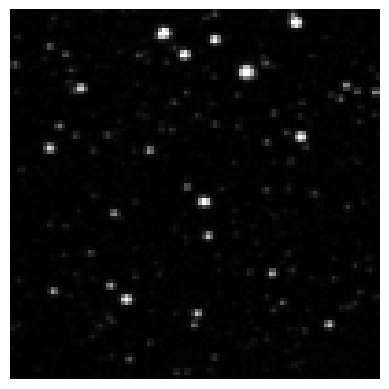

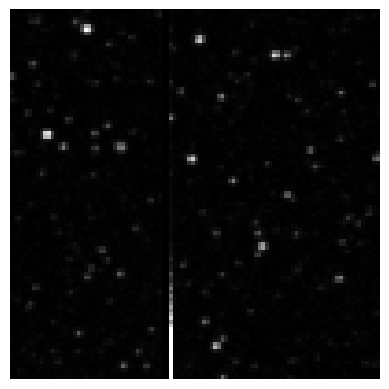

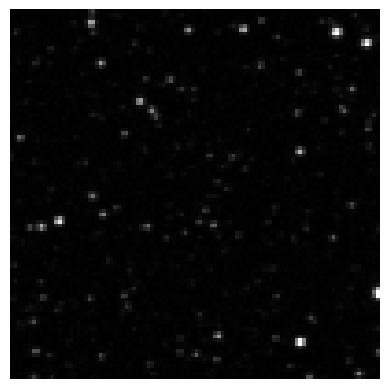

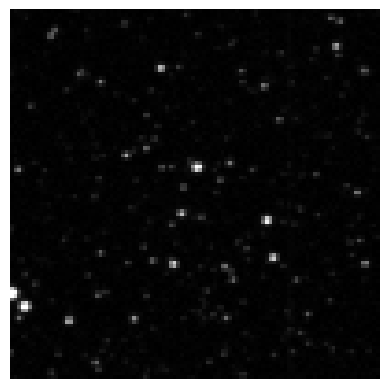

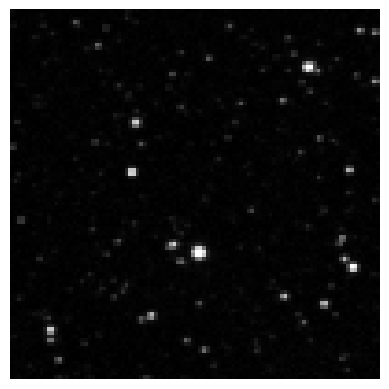

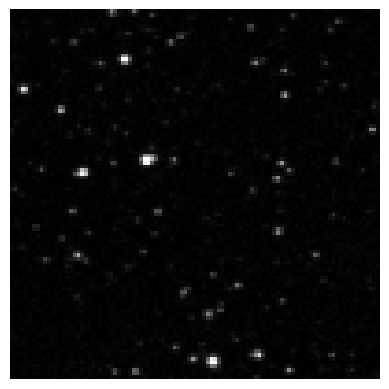

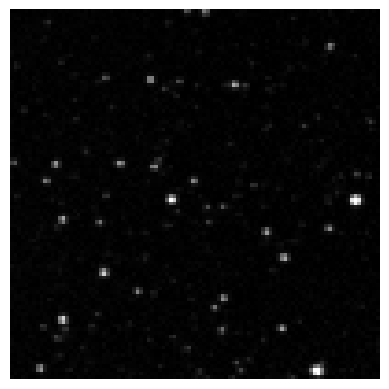

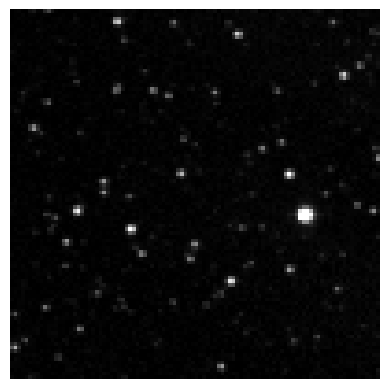

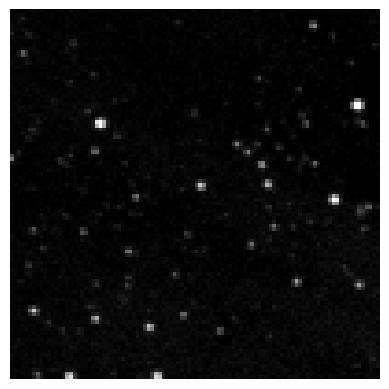

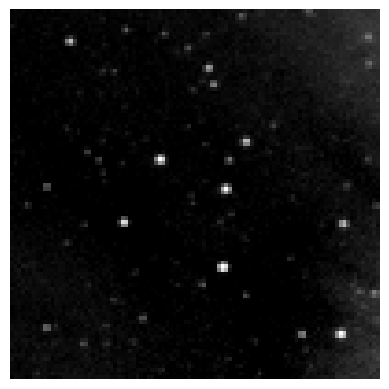

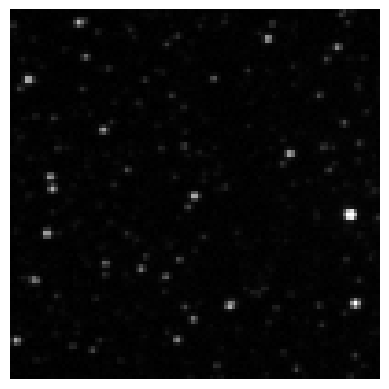

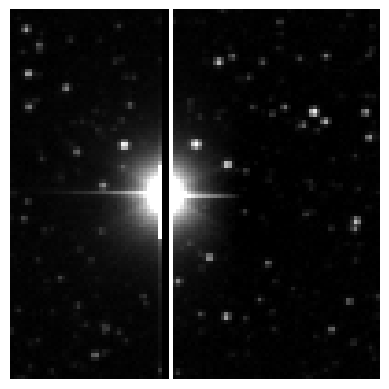

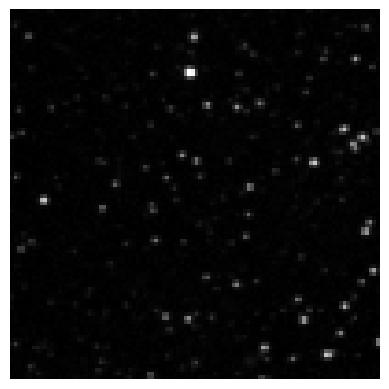

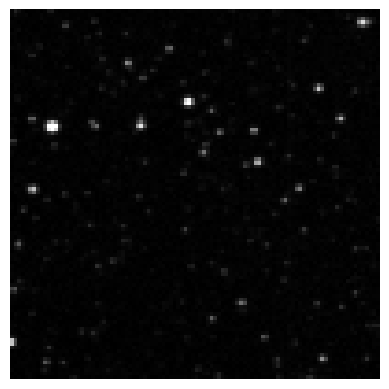

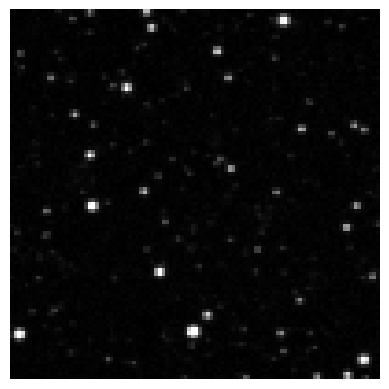

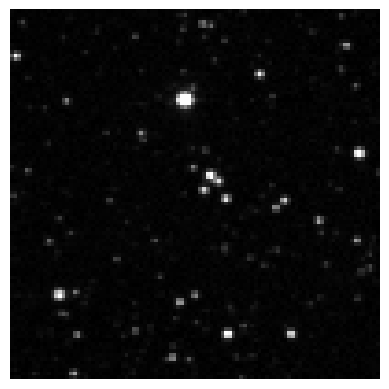

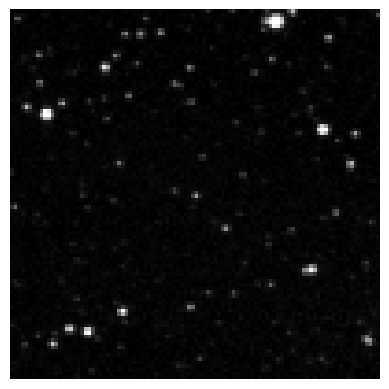

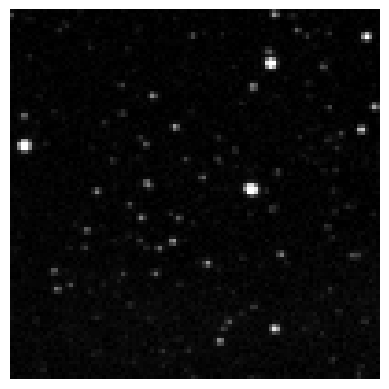

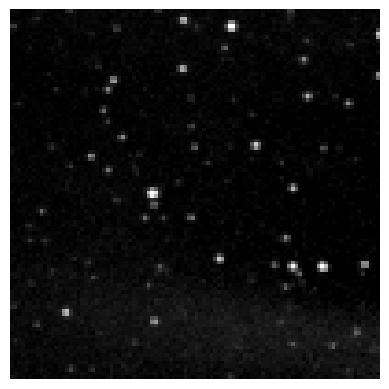

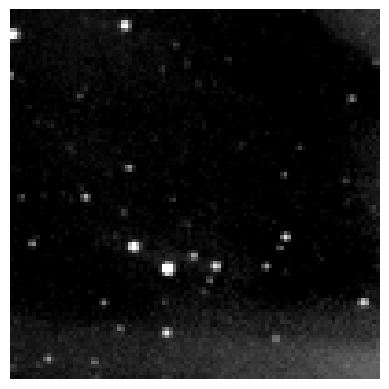

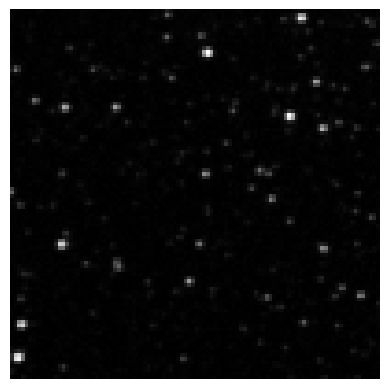

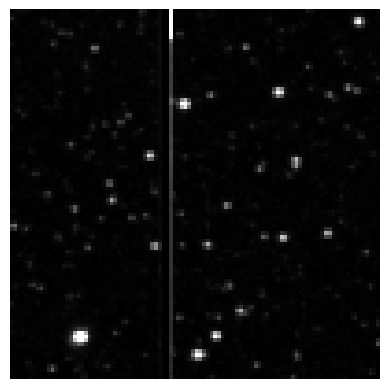

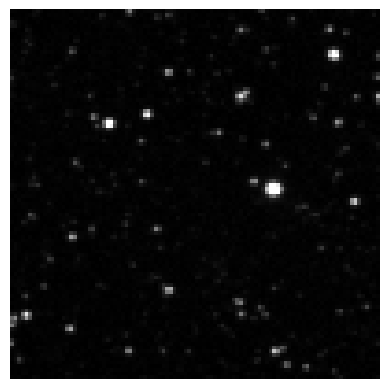

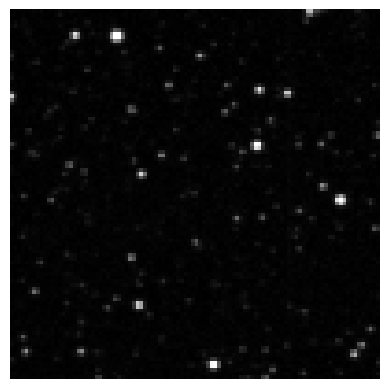

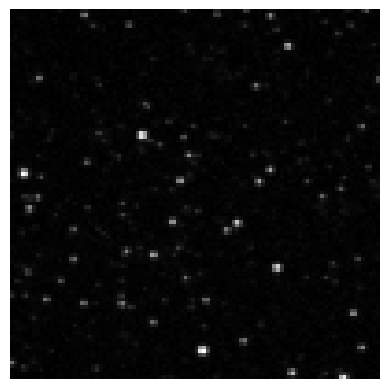

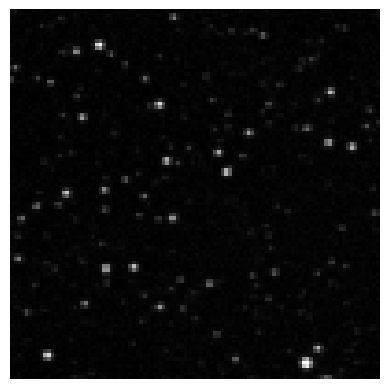

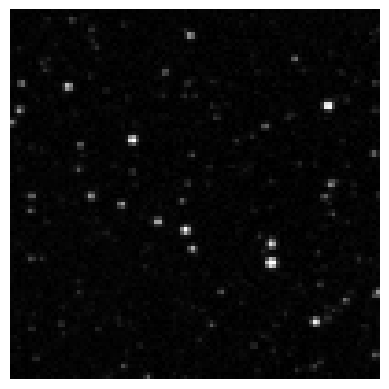

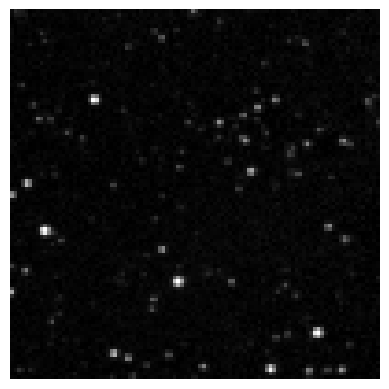

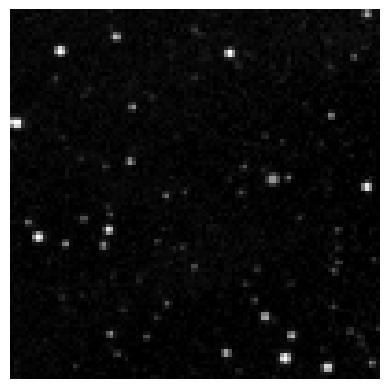

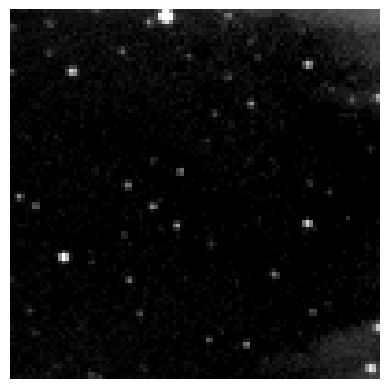

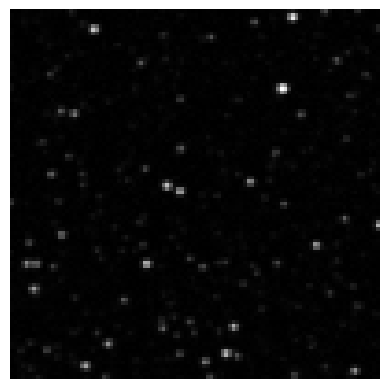

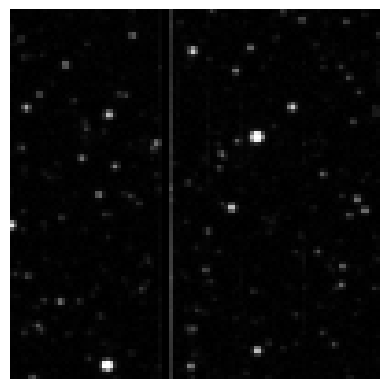

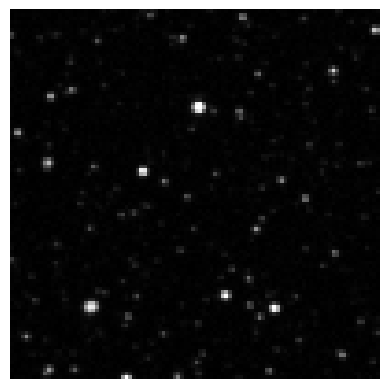

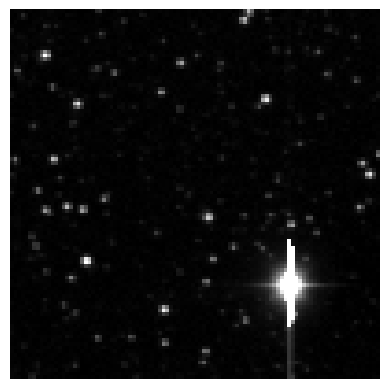

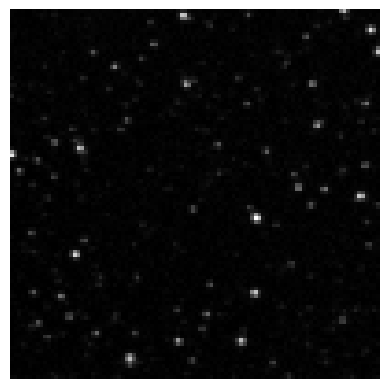

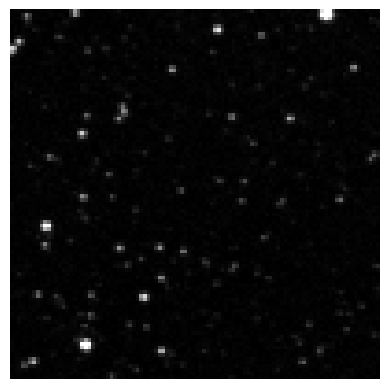

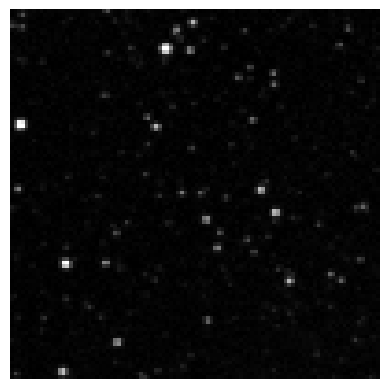

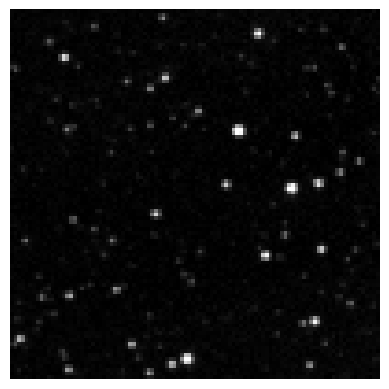

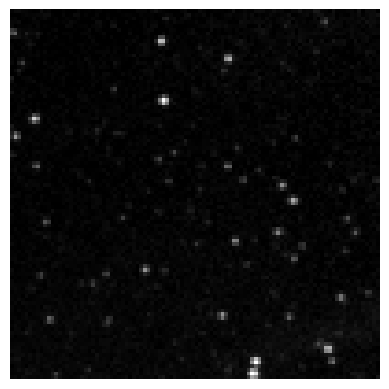

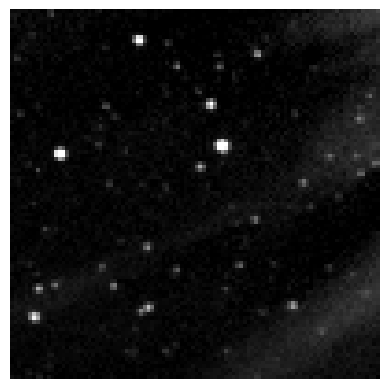

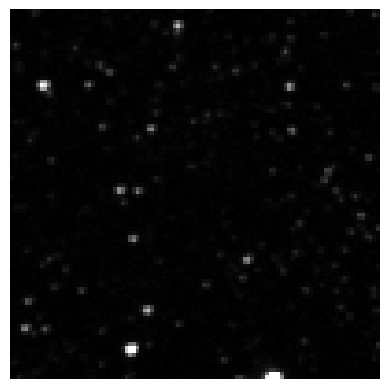

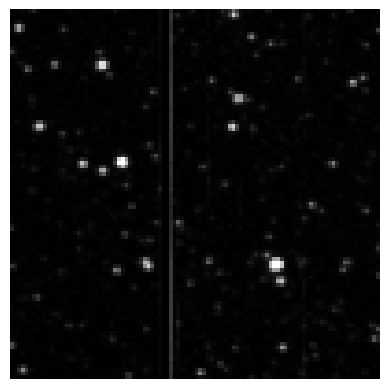

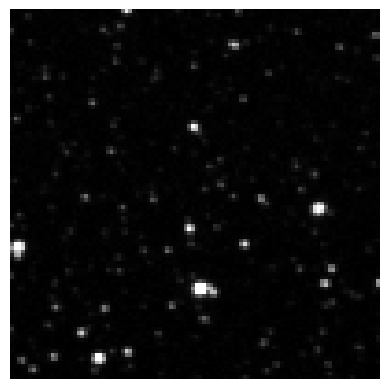

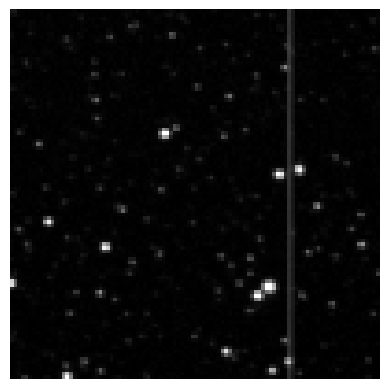

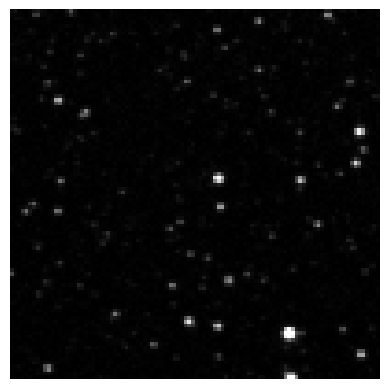

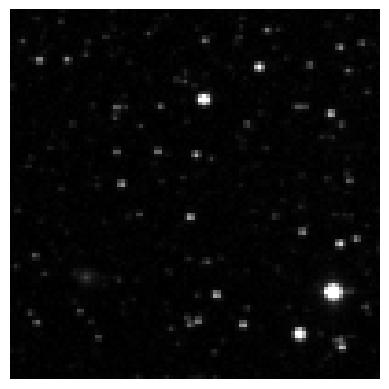

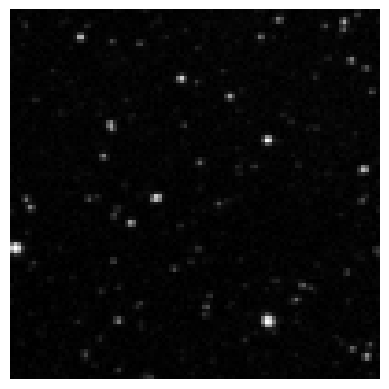

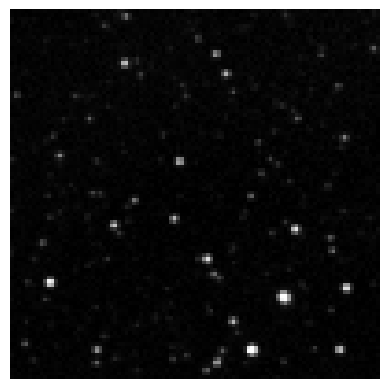

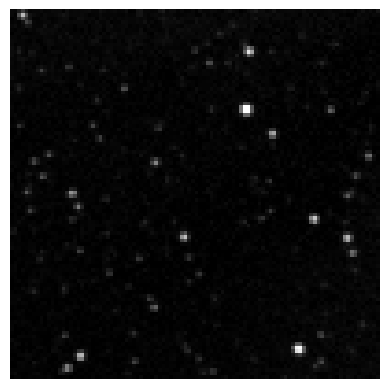

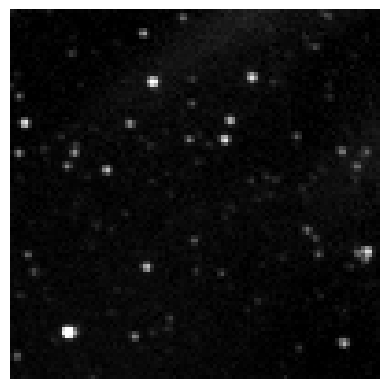

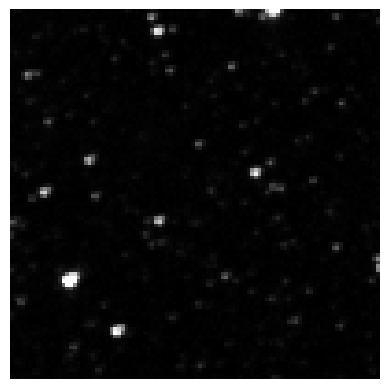

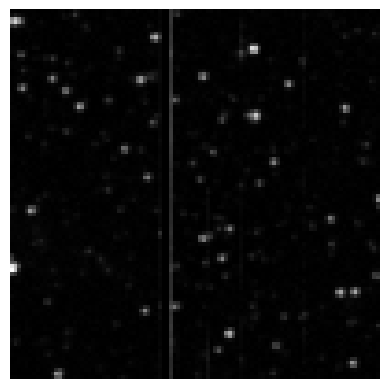

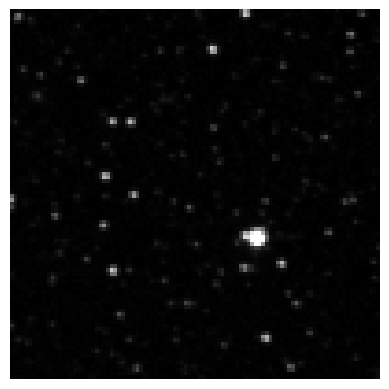

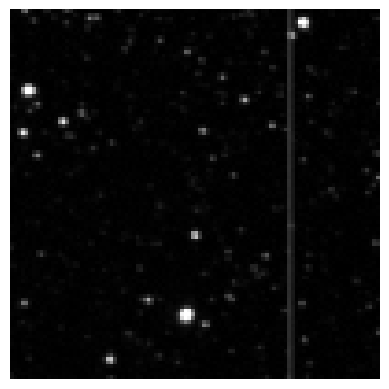

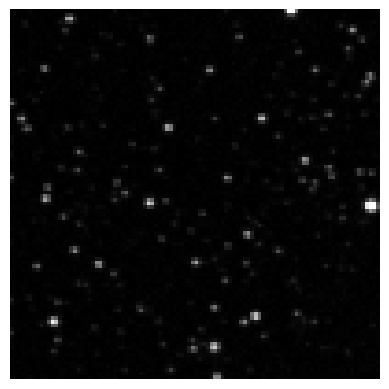

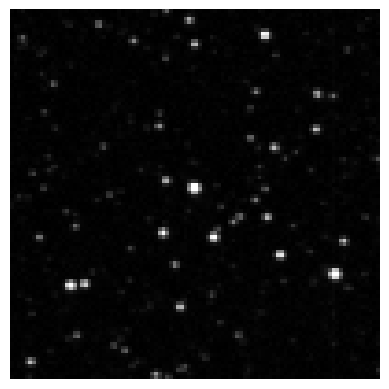

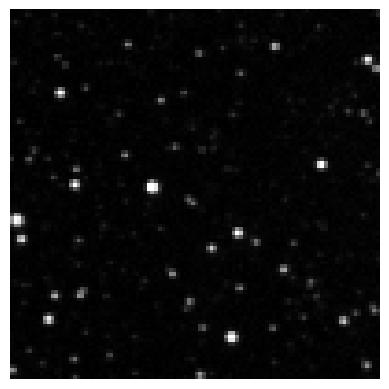

KeyboardInterrupt: 

In [152]:
for i in range(100):
    plt.imshow(patches[i].squeeze().detach().cpu(), cmap='gray')
    plt.axis('off')
    plt.show()

In [176]:
print(patches.shape)

torch.Size([100, 1, 100, 100])


In [177]:
patches = patches.to(device)

model.eval()

with torch.no_grad():
    outputs = model(patches)
    predictions = torch.argmax(outputs, dim=1)

In [178]:
print(predictions)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1], device='cuda:0')


In [179]:
probs = torch.softmax(outputs, dim=1)

print(probs[:])
print("Class 0 probability:", probs[:, 0].min().item(),
      probs[:, 0].max().item(),
      probs[:, 0].mean().item())

print("Class 1 probability:", probs[:, 1].min().item(),
      probs[:, 1].max().item(),
      probs[:, 1].mean().item())

tensor([[8.4641e-03, 9.9154e-01],
        [8.4641e-03, 9.9154e-01],
        [7.7906e-03, 9.9221e-01],
        [8.2705e-03, 9.9173e-01],
        [2.3767e-03, 9.9762e-01],
        [5.6289e-03, 9.9437e-01],
        [8.4641e-03, 9.9154e-01],
        [6.5357e-03, 9.9346e-01],
        [6.5029e-03, 9.9350e-01],
        [2.1850e-03, 9.9782e-01],
        [3.7721e-03, 9.9623e-01],
        [8.4641e-03, 9.9154e-01],
        [5.9396e-03, 9.9406e-01],
        [8.4641e-03, 9.9154e-01],
        [9.6736e-10, 1.0000e+00],
        [6.8918e-09, 1.0000e+00],
        [6.4618e-03, 9.9354e-01],
        [7.8504e-03, 9.9215e-01],
        [8.4499e-03, 9.9155e-01],
        [6.3356e-03, 9.9366e-01],
        [7.6461e-03, 9.9235e-01],
        [1.2561e-02, 9.8744e-01],
        [2.6607e-03, 9.9734e-01],
        [5.2278e-03, 9.9477e-01],
        [8.4641e-03, 9.9154e-01],
        [3.0070e-09, 1.0000e+00],
        [8.0788e-03, 9.9192e-01],
        [8.3818e-03, 9.9162e-01],
        [7.3558e-03, 9.9264e-01],
        [3.942

In [180]:
probs = probs.round(decimals = 4)

In [181]:
def confidence_map(images,probs):
    fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(30, 30))
    axs = axs.flatten()
    
    for i, img in enumerate(images):
        axs[i].imshow(img, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    #patches[i].squeeze().detach().cpu()

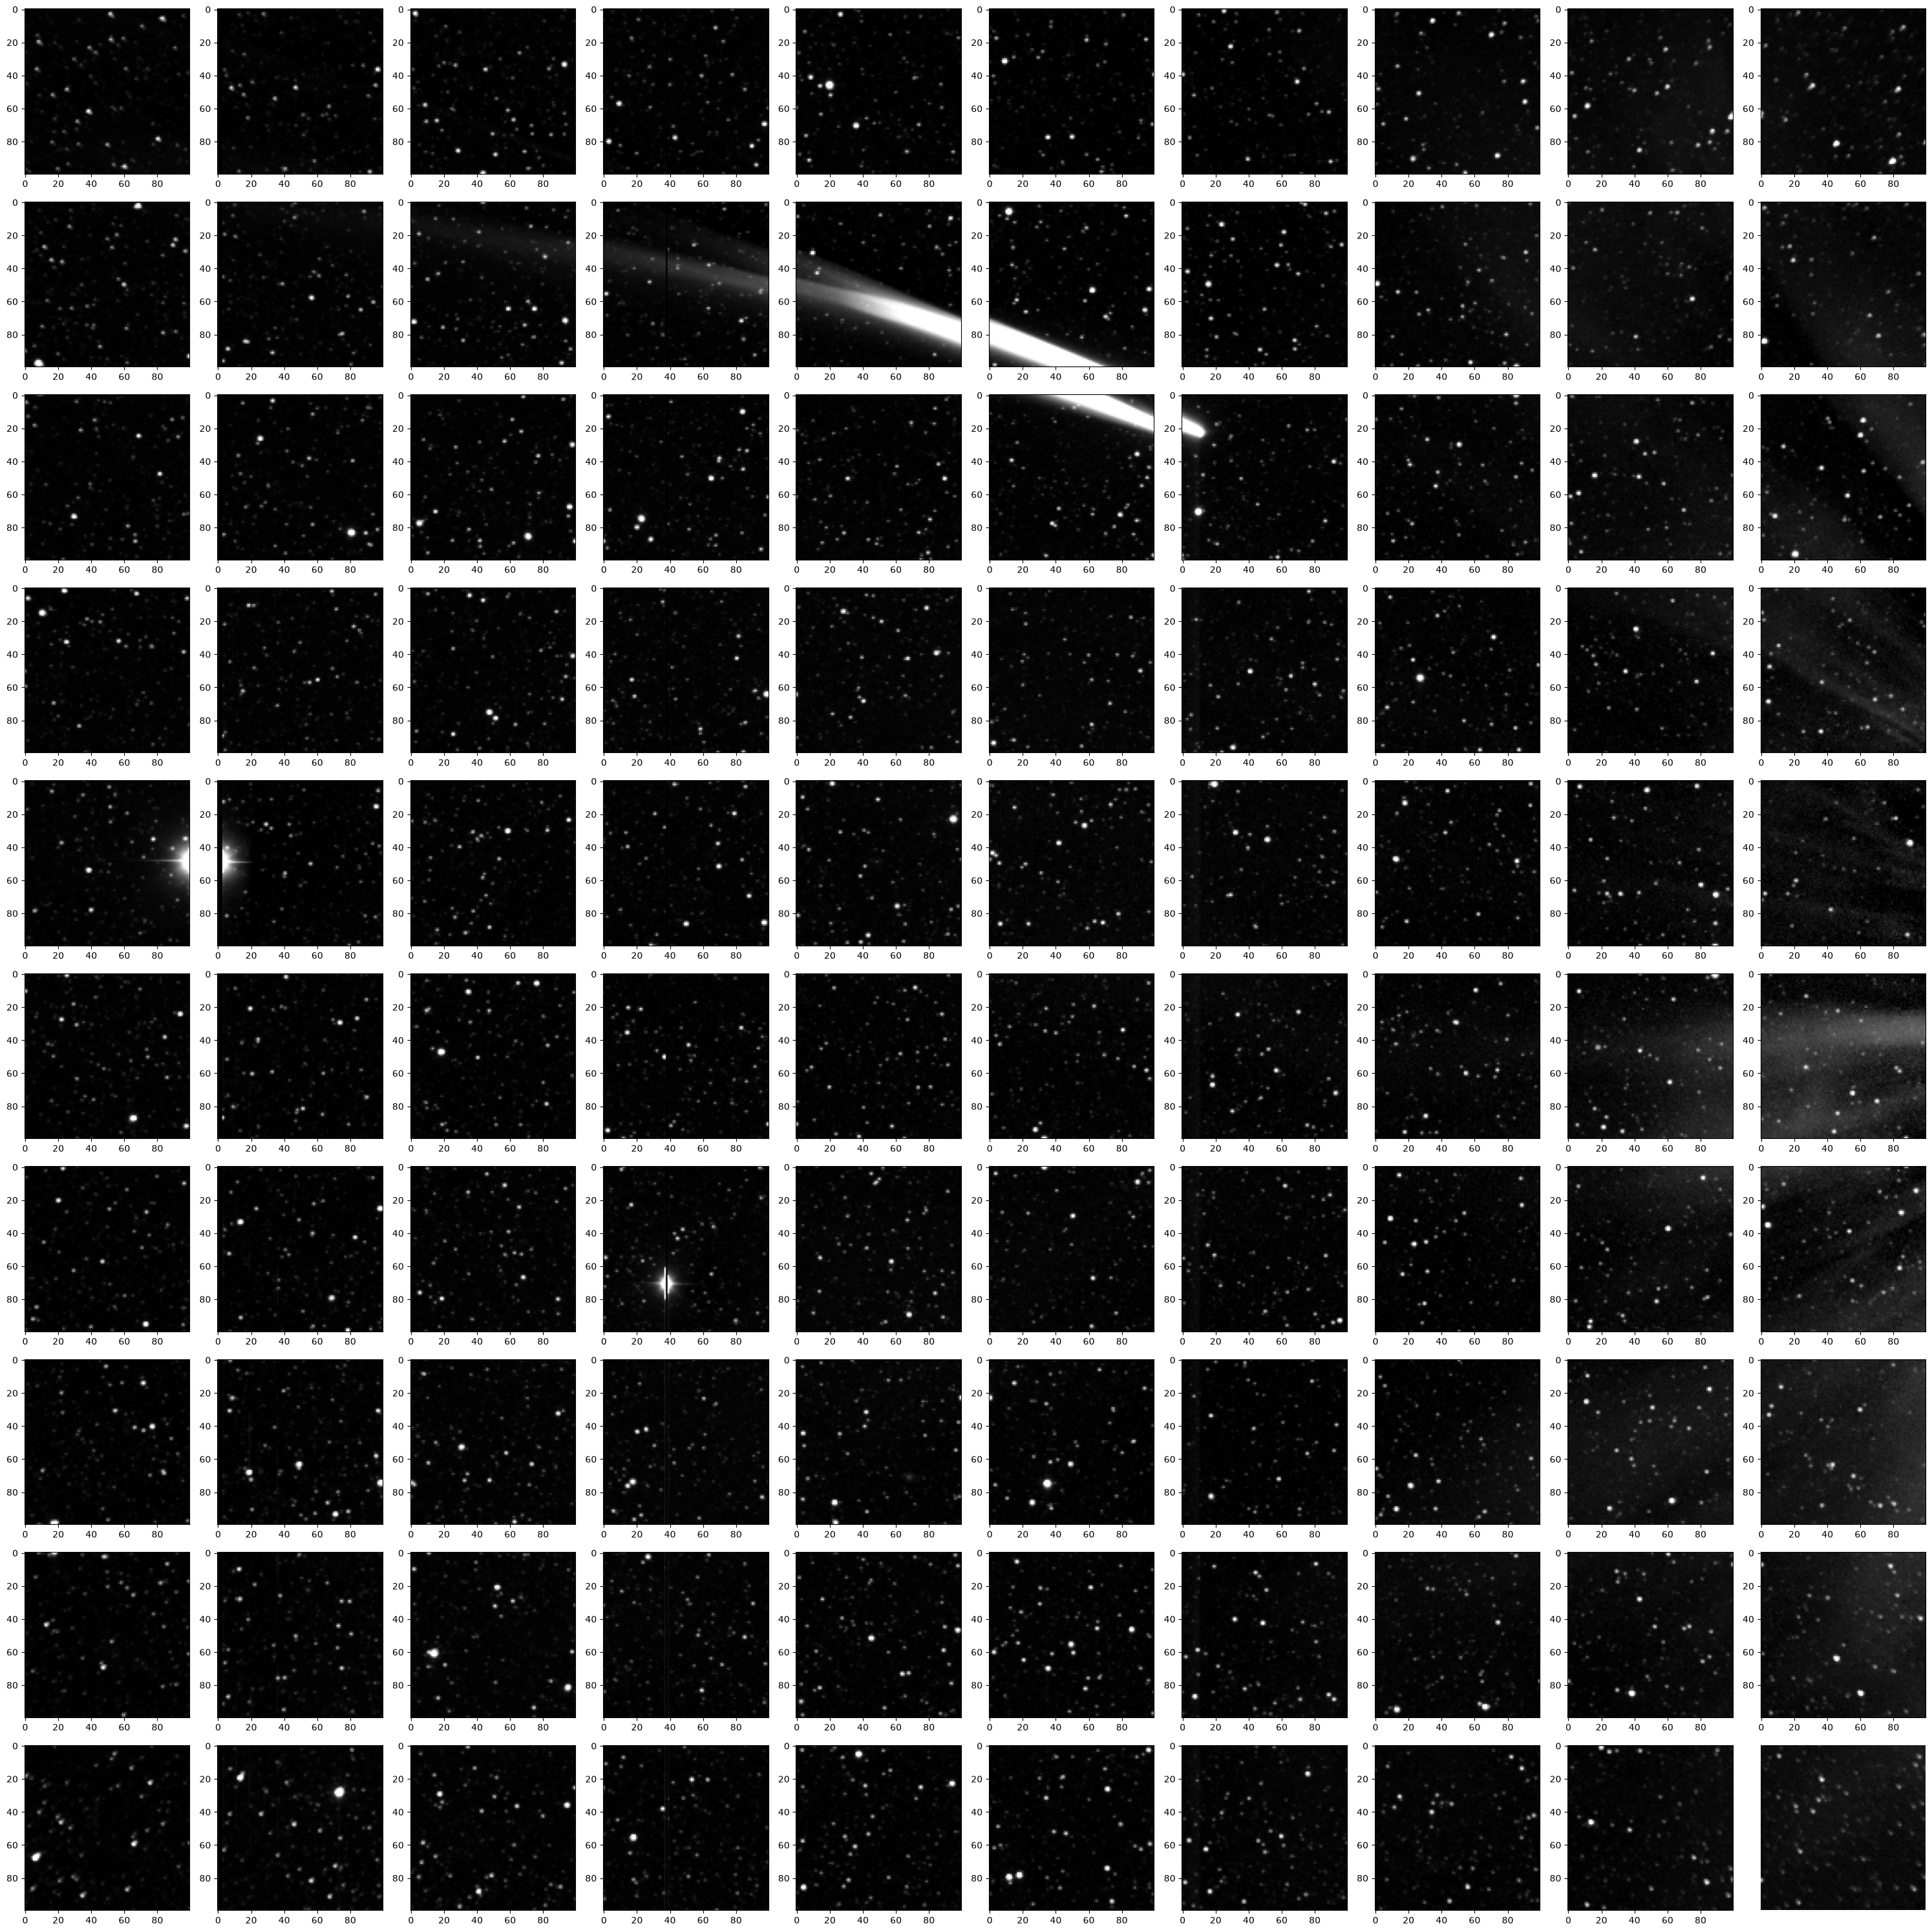

In [182]:
confidence_map(patches.squeeze().detach().cpu(),probs)

In [183]:
label0_probs = []

for j in range(10):
    temp = []
    for i in range(0+j*10,10+j*10):
        temp.append(probs[i][0].item())
    label0_probs.append(temp)


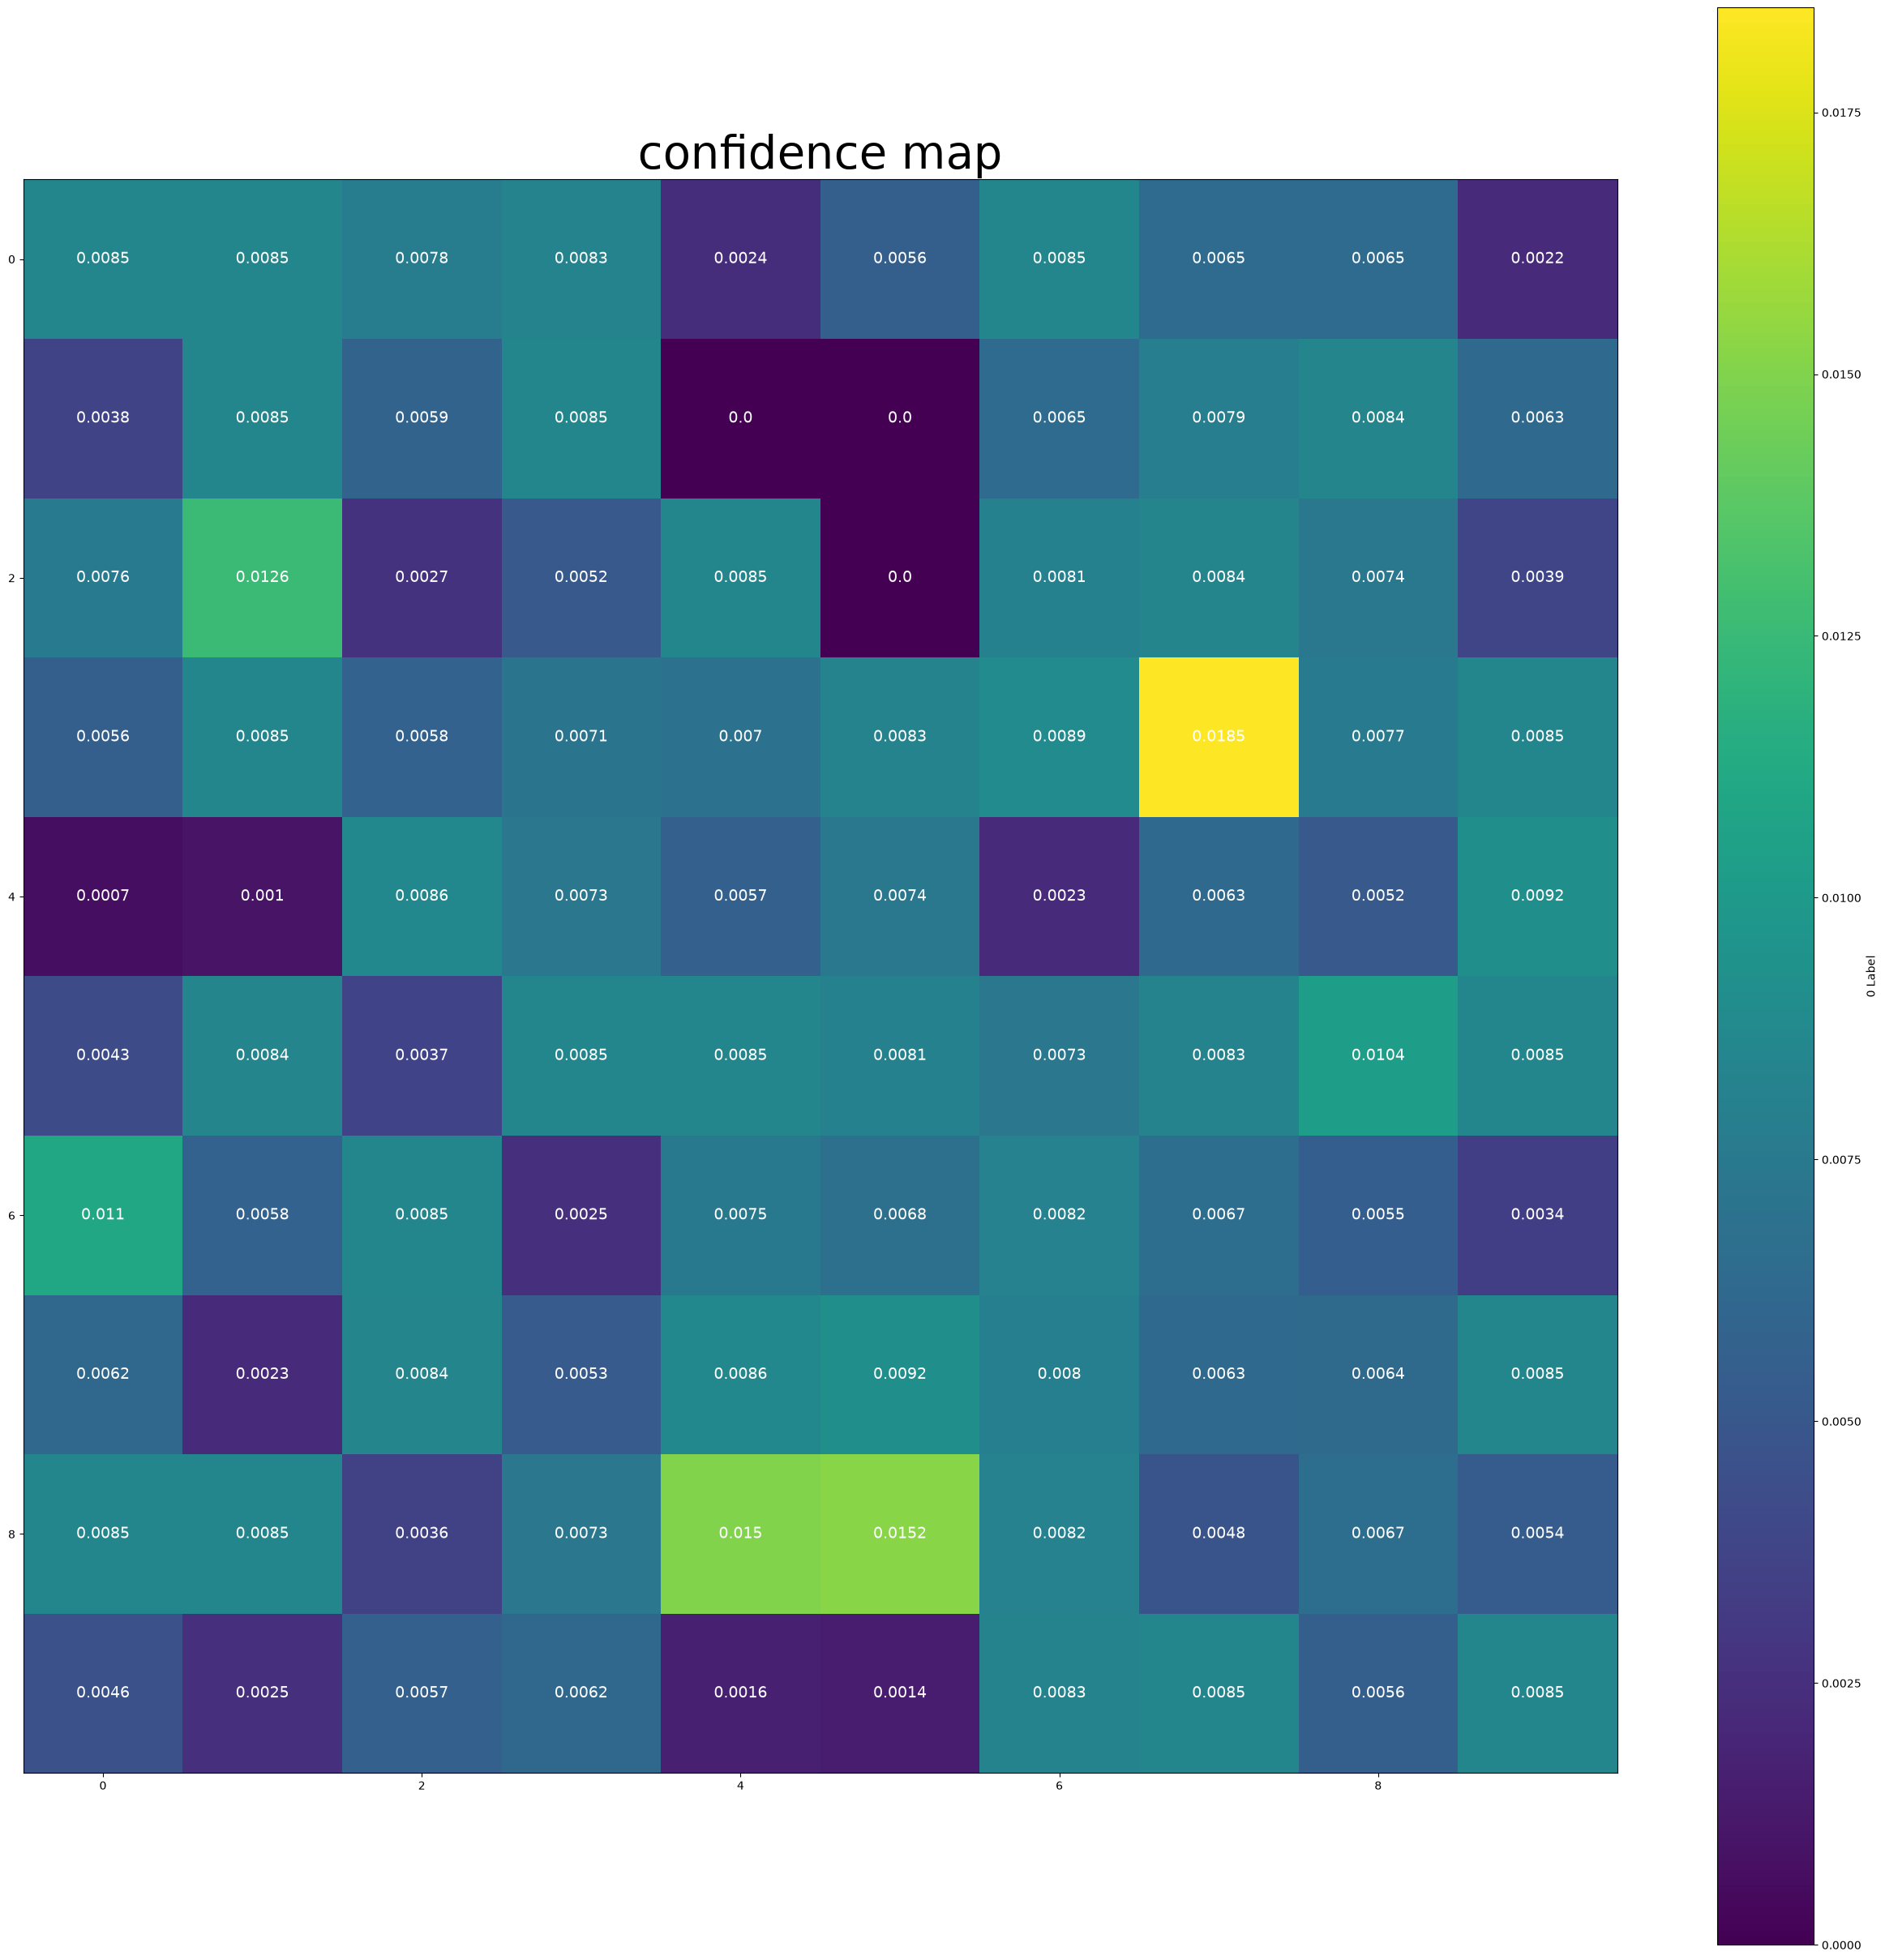

In [184]:
fig, ax = plt.subplots(figsize=(25, 25))
im = ax.imshow(label0_probs)

h = 0
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, round(label0_probs[i][j],5), ha="center", va="center", color="w", fontsize=14)
ax.set_title("confidence map", fontsize= 40)
fig.tight_layout()
plt.colorbar(im, label='0 Label')
plt.show()

In [37]:
def create_imageGrid(image_paths, rows, cols, thumb_size=(200, 200)):
    # Calculate the total canvas size
    grid_w = cols * thumb_size[0]
    grid_h = rows * thumb_size[1]
    grid_img = Image.new("RGB", (grid_w, grid_h), color="white")
    
    for index, path in enumerate(image_paths):
        if index >= rows * cols:
            break
            
        # Open and resize each image
        img = Image.open(path)
        img = img.resize(thumb_size)
        
        # Calculate X and Y coordinates
        x = (index % cols) * thumb_size[0]
        y = (index // cols) * thumb_size[1]
        
        # Paste the image onto the grid canvas
        grid_img.paste(img, (x, y))
        
    return grid_img

In [224]:
values, indices = torch.topk(probs[:, 0], k=3)

print("Highest:", values[0].item(), "at index:", indices[0].item())
print("Second:", values[1].item(), "at index:", indices[1].item())
print("Third", values[2].item(), "at index:", indices[2].item())

Highest: 0.0885140523314476 at index: 3
Second: 0.0482899434864521 at index: 4
Third 0.0482899434864521 at index: 0


In [165]:
print(dataset.class_to_idx)

{'comet': 0, 'no comet': 1}


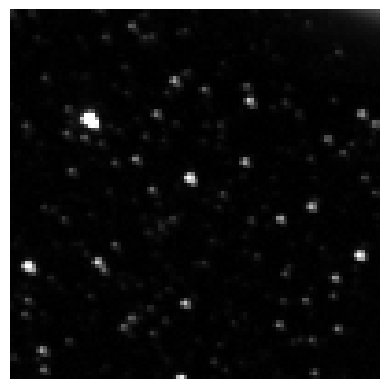

In [166]:
# image_100 = image_100.to(device)
# outputs = model(image_100)

# ConfusionMatrixDisplay.from_predictions(
#     y_true=true_labels,
#     y_pred=0,
#     display_labels=["comet", "no comet"],  # Custom text labels
#     cmap=plt.cm.Blues                      # Color theme
# )


patches[1] = patches[1].to(torch.device("cpu"))
plt.imshow(patches[1].squeeze().detach().cpu(), cmap='gray')
plt.axis('off')
plt.show()
# # print(outputs)